# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [164]:
from src.chromatin_model import ChromatinModel
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs('distinct')

chromatin_model1 = ChromatinModel(config1)

todo: Loading testing config from replication deconvolution


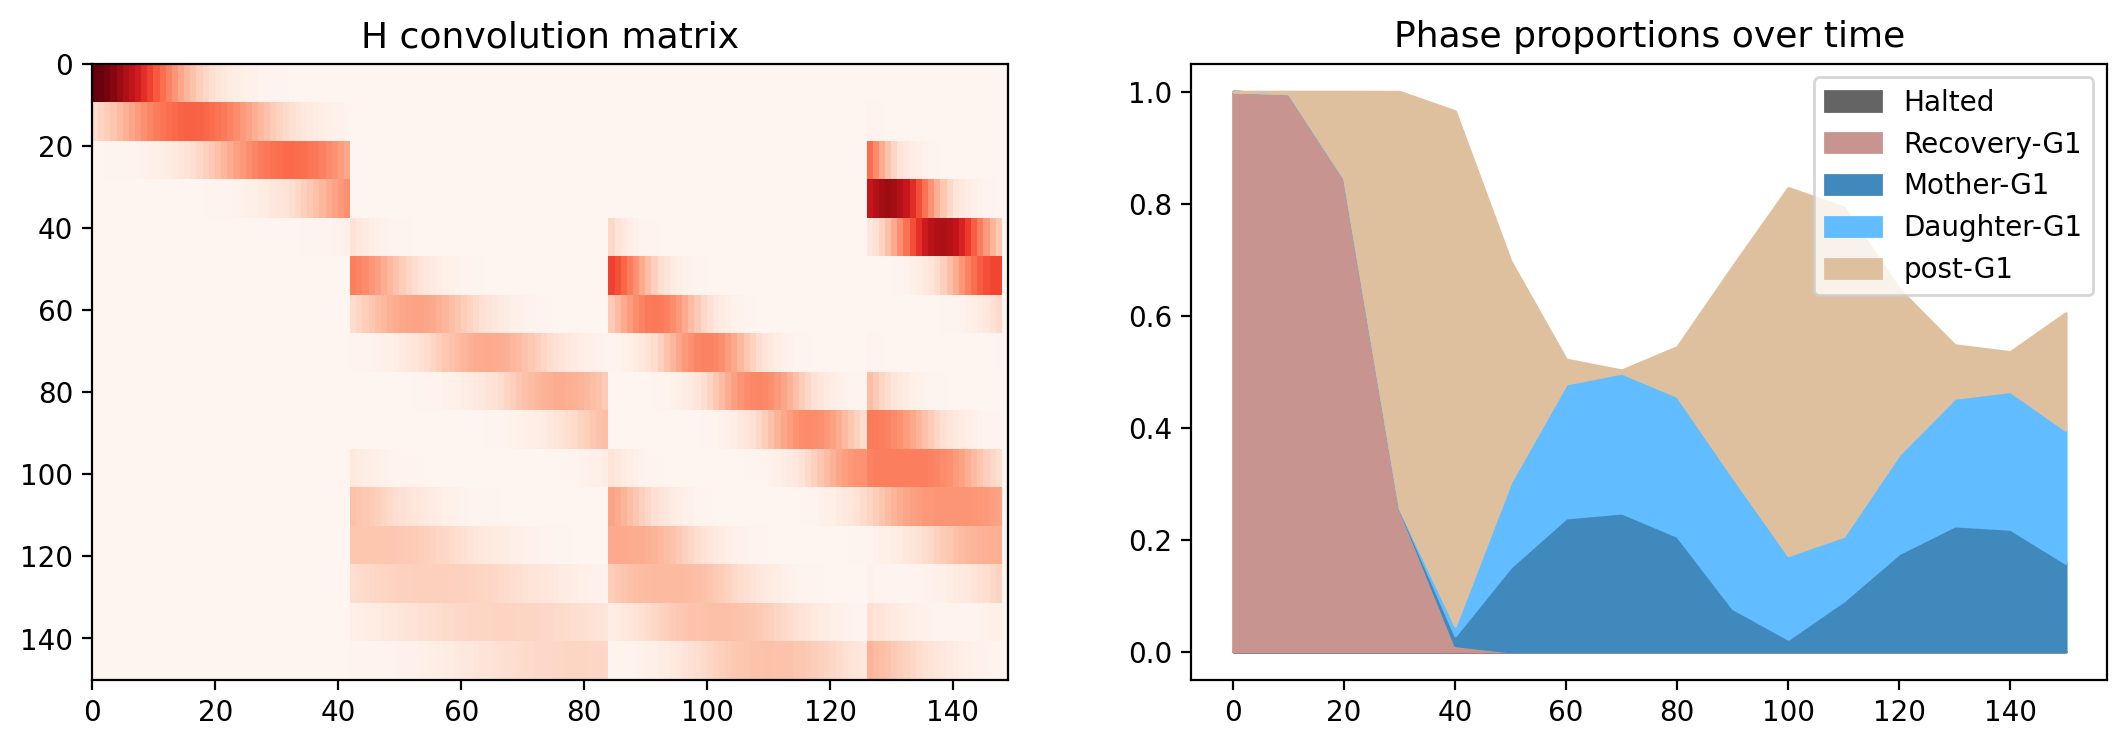

In [165]:
config1.plot_H()

In [3]:
mnase_span = 758500, 759500
chromatin_model1.load_mnase_span(chrom=14, mnase_span=mnase_span)

Loading chromosome reads: 14
Applying a normalization for length distribution


In [4]:
from src.chromatin_deconvolution_solver import example_N_frep_b

padding_type = 'both'
N, f_rep, b = example_N_frep_b(config1)


In [6]:
from src.chromatin_gamma_search import ChromatinFindOptimalGamma
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

chromatin_solver = ChromatinDeconvolveSolver(config1, 
    chromatin_model1.G, N, b, f_rep,
    padding_type='both', subsample=5)

Subsampling to top 5 sites
Indices with the highest max value:  [1734 1972 1754 1773 1773 1773 1816 1734 1972 1754 1773 1773 1653 1671
 1570 1773]


In [43]:
chrom_find_gamma = ChromatinFindOptimalGamma(chromatin_solver, gamma_min=0.00001,
                                             gamma_max=0.0001)

	Base error (γ=0):	rn: 0.018333	sn: 223.612298
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.0192491
			Absolute (e0 + 0.04): 0.0583325
			Chosen: 0.019249
		Right:
			Relative (1.40 * e0): 0.0256655
			Absolute (e0 + 0.32): 0.338333
			Chosen: 0.338333
	Searching for left boundary gamma...
		γ: 5.5e-05	rn: 0.0269	sn: 1.4502
		γ: 3.25e-05	rn: 0.0256	sn: 1.6538
		γ: 2.125e-05	rn: 0.0241	sn: 2.0416
		γ: 1.5625e-05	rn: 0.0233	sn: 2.2978
		γ: 1.28125e-05	rn: 0.0230	sn: 2.4495
		γ: 1.14062e-05	rn: 0.0228	sn: 2.5460
		γ: 1.07031e-05	rn: 0.0227	sn: 2.6334
	Left boundary gamma found: 1.03516e-05
	Searching for right boundary gamma...
		γ: 5.51758e-05	rn: 0.0269	sn: 1.4490
		γ: 7.75879e-05	rn: 0.0286	sn: 1.2890
		γ: 8.87939e-05	rn: 0.0299	sn: 1.1882
		γ: 9.4397e-05	rn: 0.0303	sn: 1.1653
		γ: 9.71985e-05	rn: 0.0305	sn: 1.1536
		γ: 9.85992e-05	rn: 0.0307	sn: 1.1465
		γ: 9.92996e-05	rn: 0.0307	sn: 1.1433
	Right boundary gamma found: 9.96498e-05
Finding elbow in the curve, selecting 20 bins

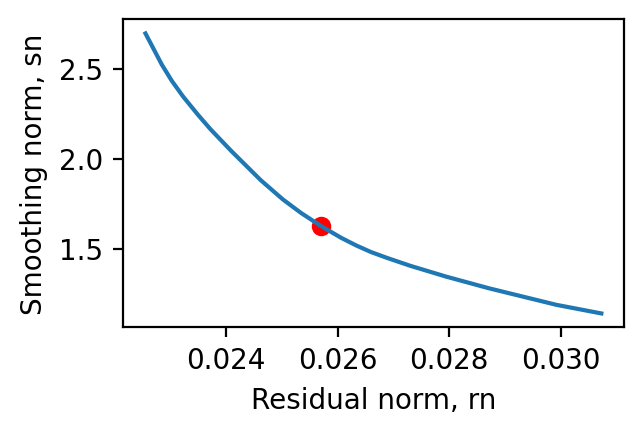

In [44]:
chrom_find_gamma.find_optimal_gamma()

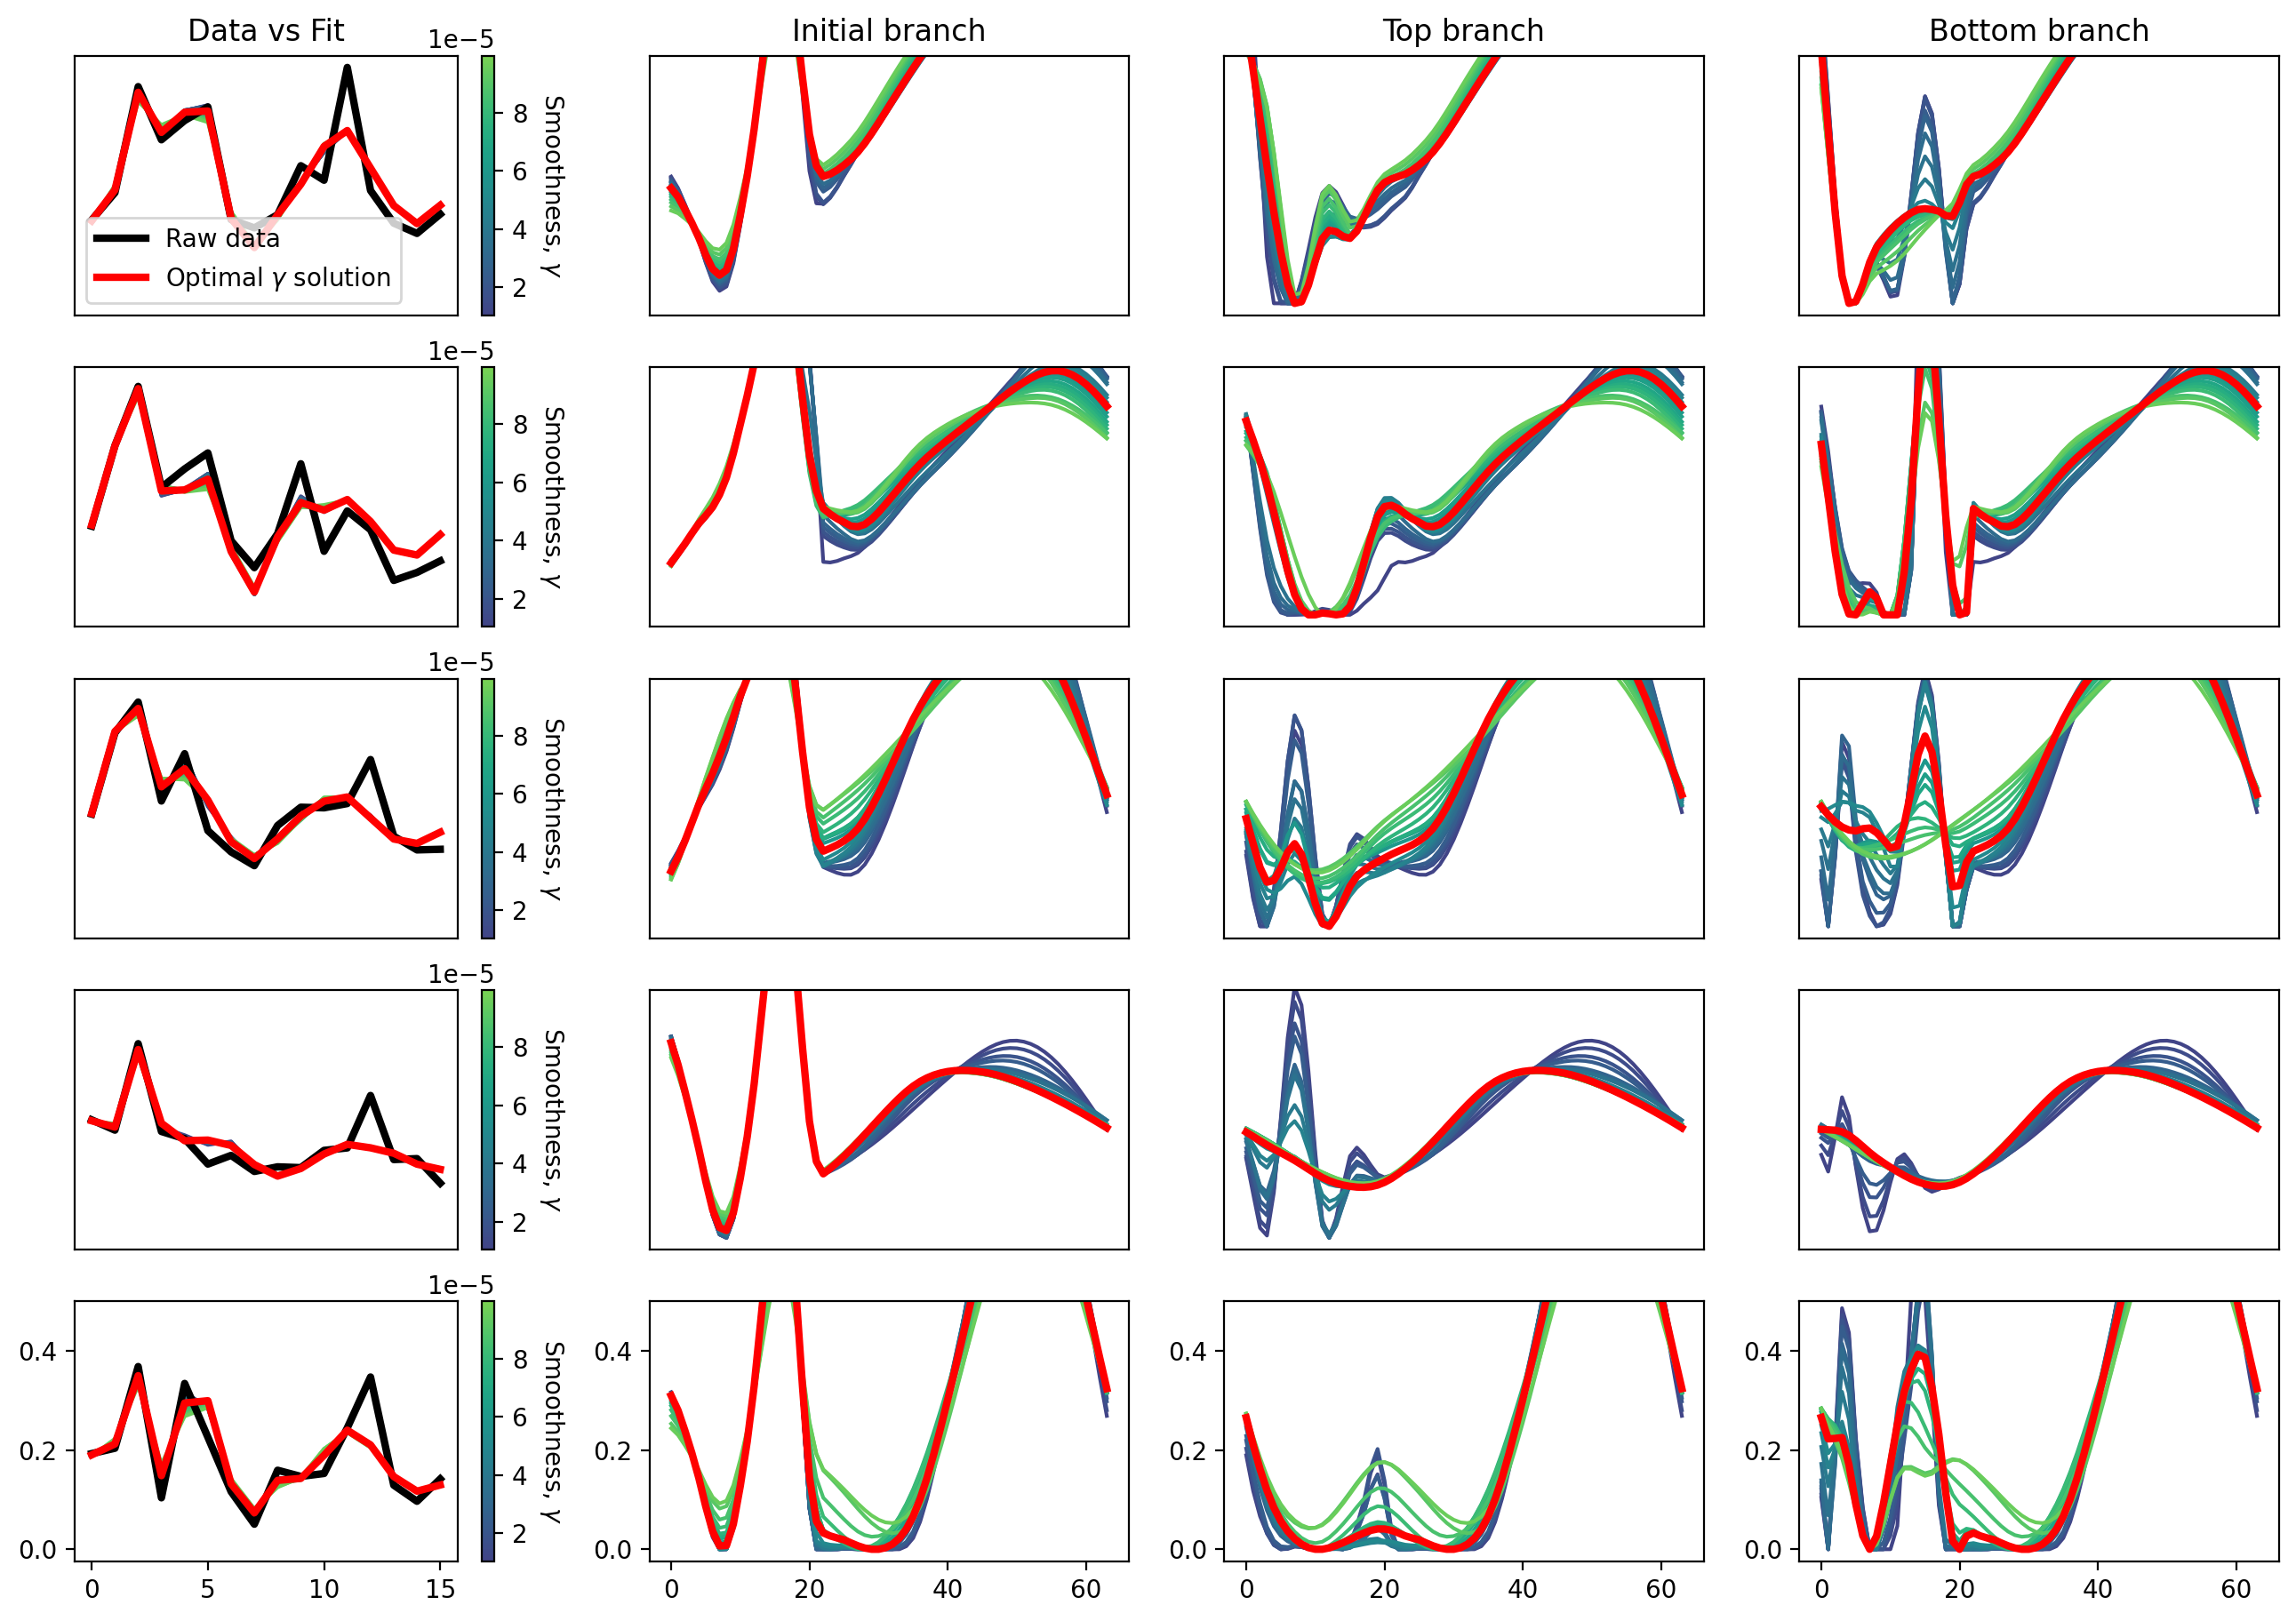

In [45]:
gamma_predicted_Gs_test = chrom_find_gamma.plot_gamma_sweep()

In [63]:
chromatin_solver_full = ChromatinDeconvolveSolver(config1, 
    chromatin_model1.G, N, b, f_rep, padding_type=padding_type)
full_deconvolved_F = chromatin_solver_full.deconvolve_G_iteratively(
   gamma=2e-4)


0/2600 - 00:00:00.001
500/2600 - 00:00:04.029
1000/2600 - 00:00:41.706
1500/2600 - 00:01:23.053
2000/2600 - 00:02:01.057
2500/2600 - 00:02:36.210


In [370]:
#from src.chromatin_model import plot_prediction
#plot_prediction(chromatin_model, N, full_deconvolved_F, f_rep, b)

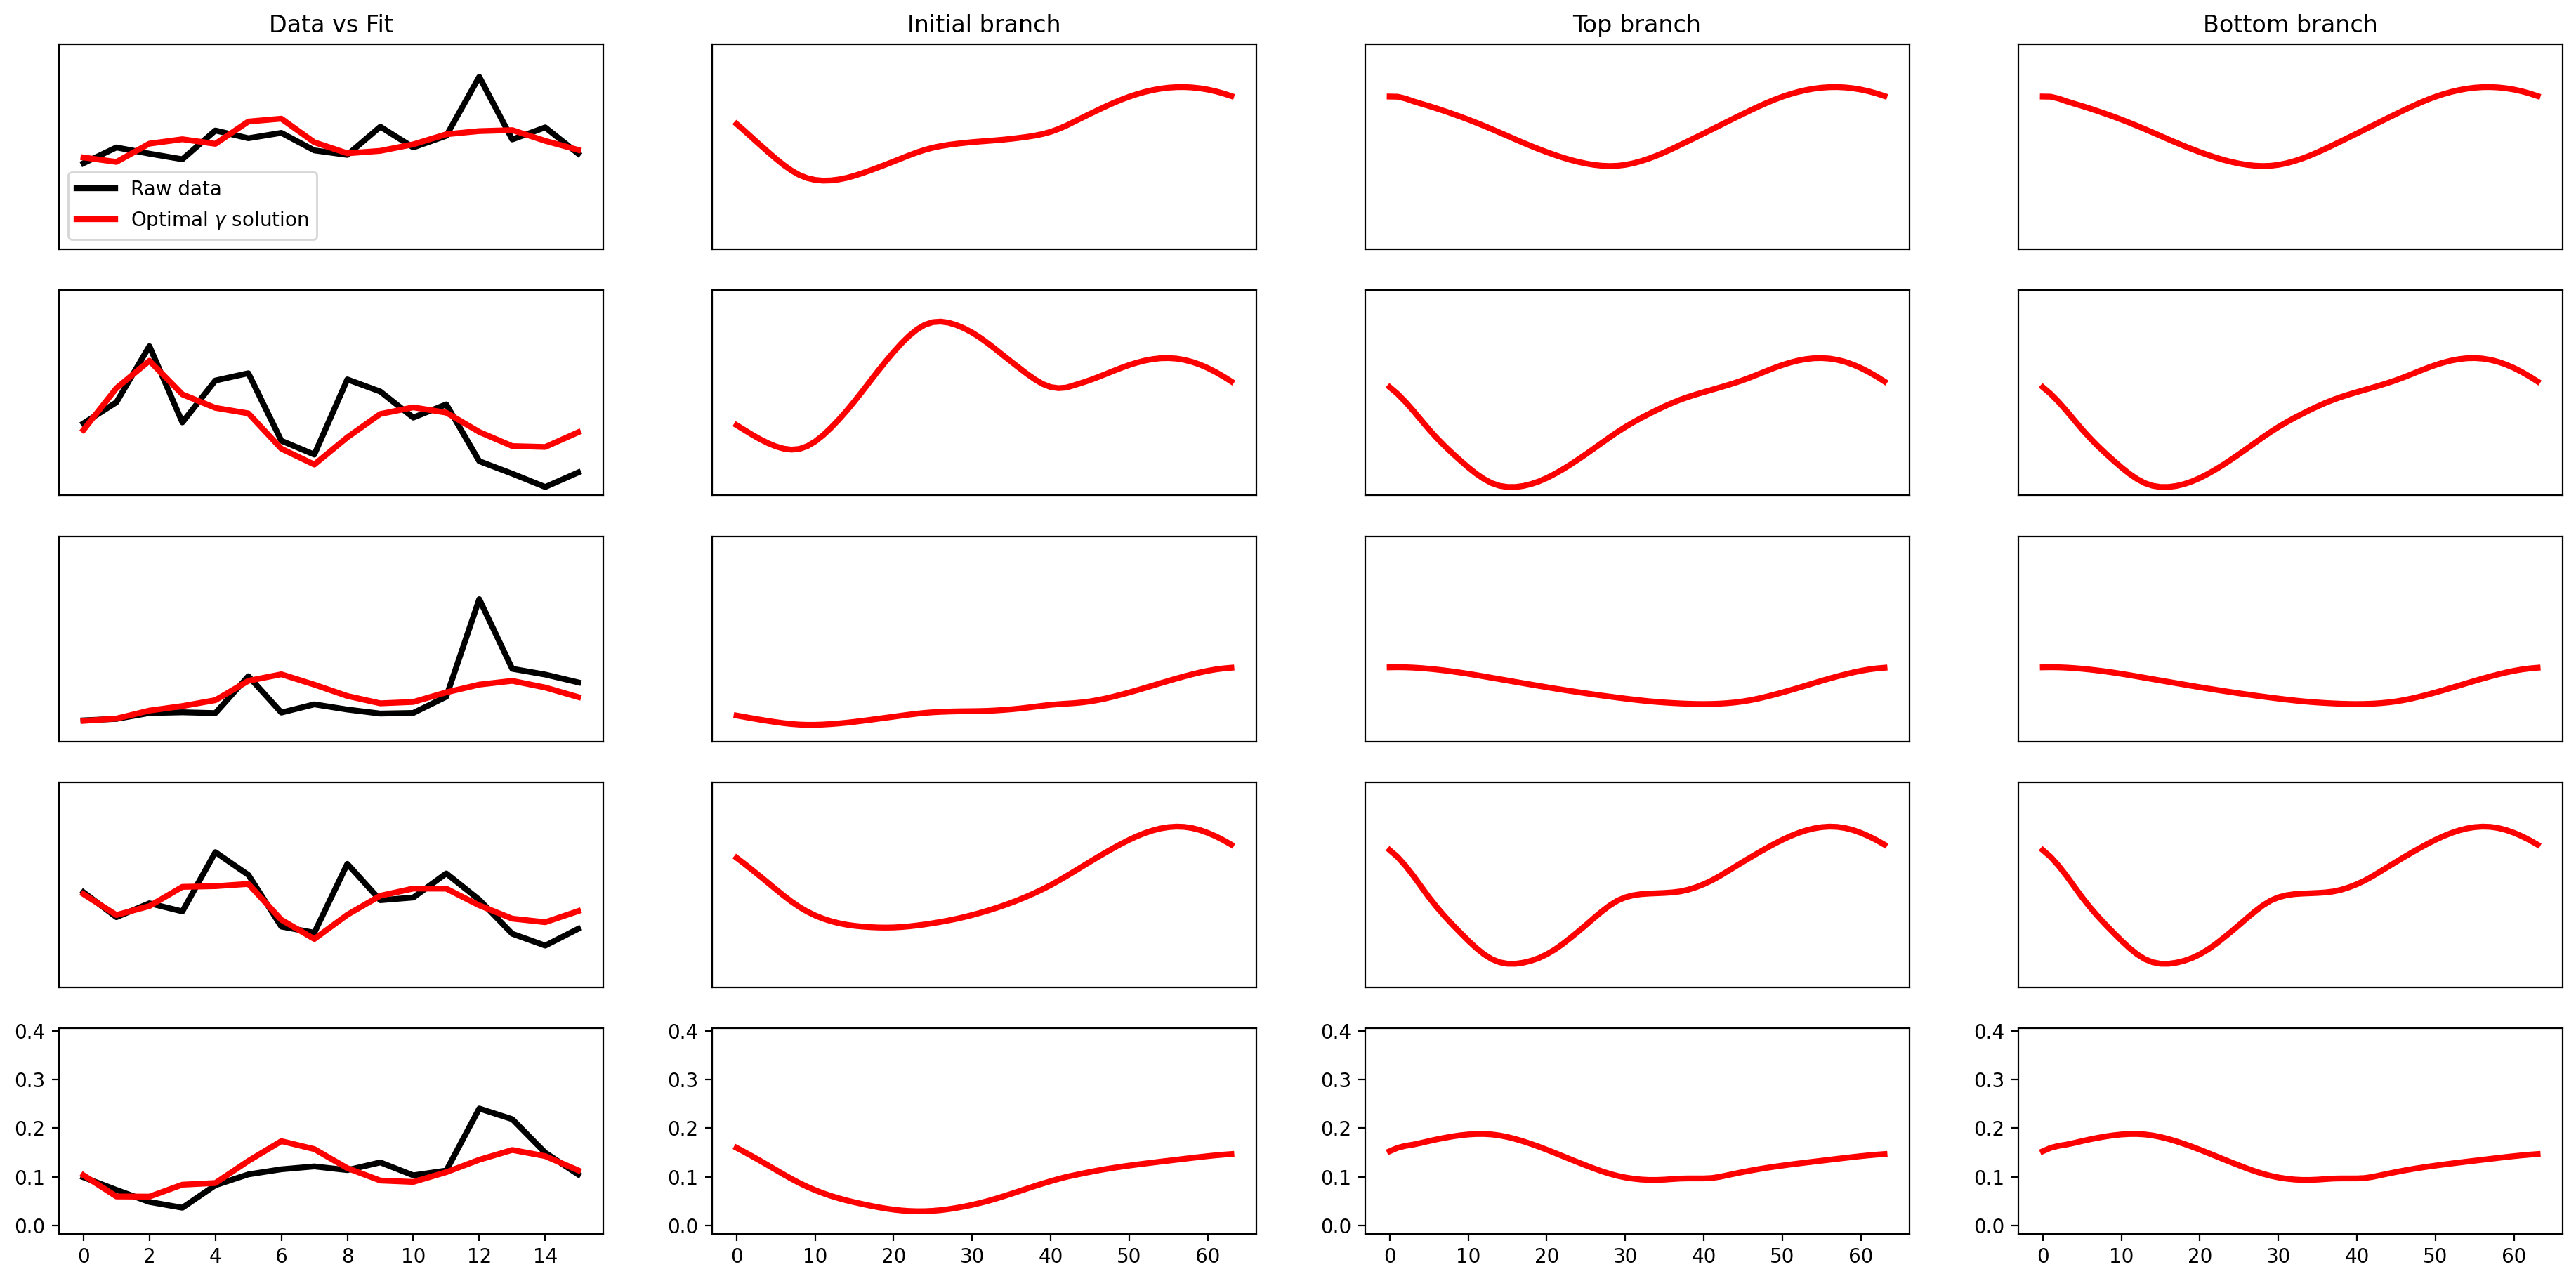

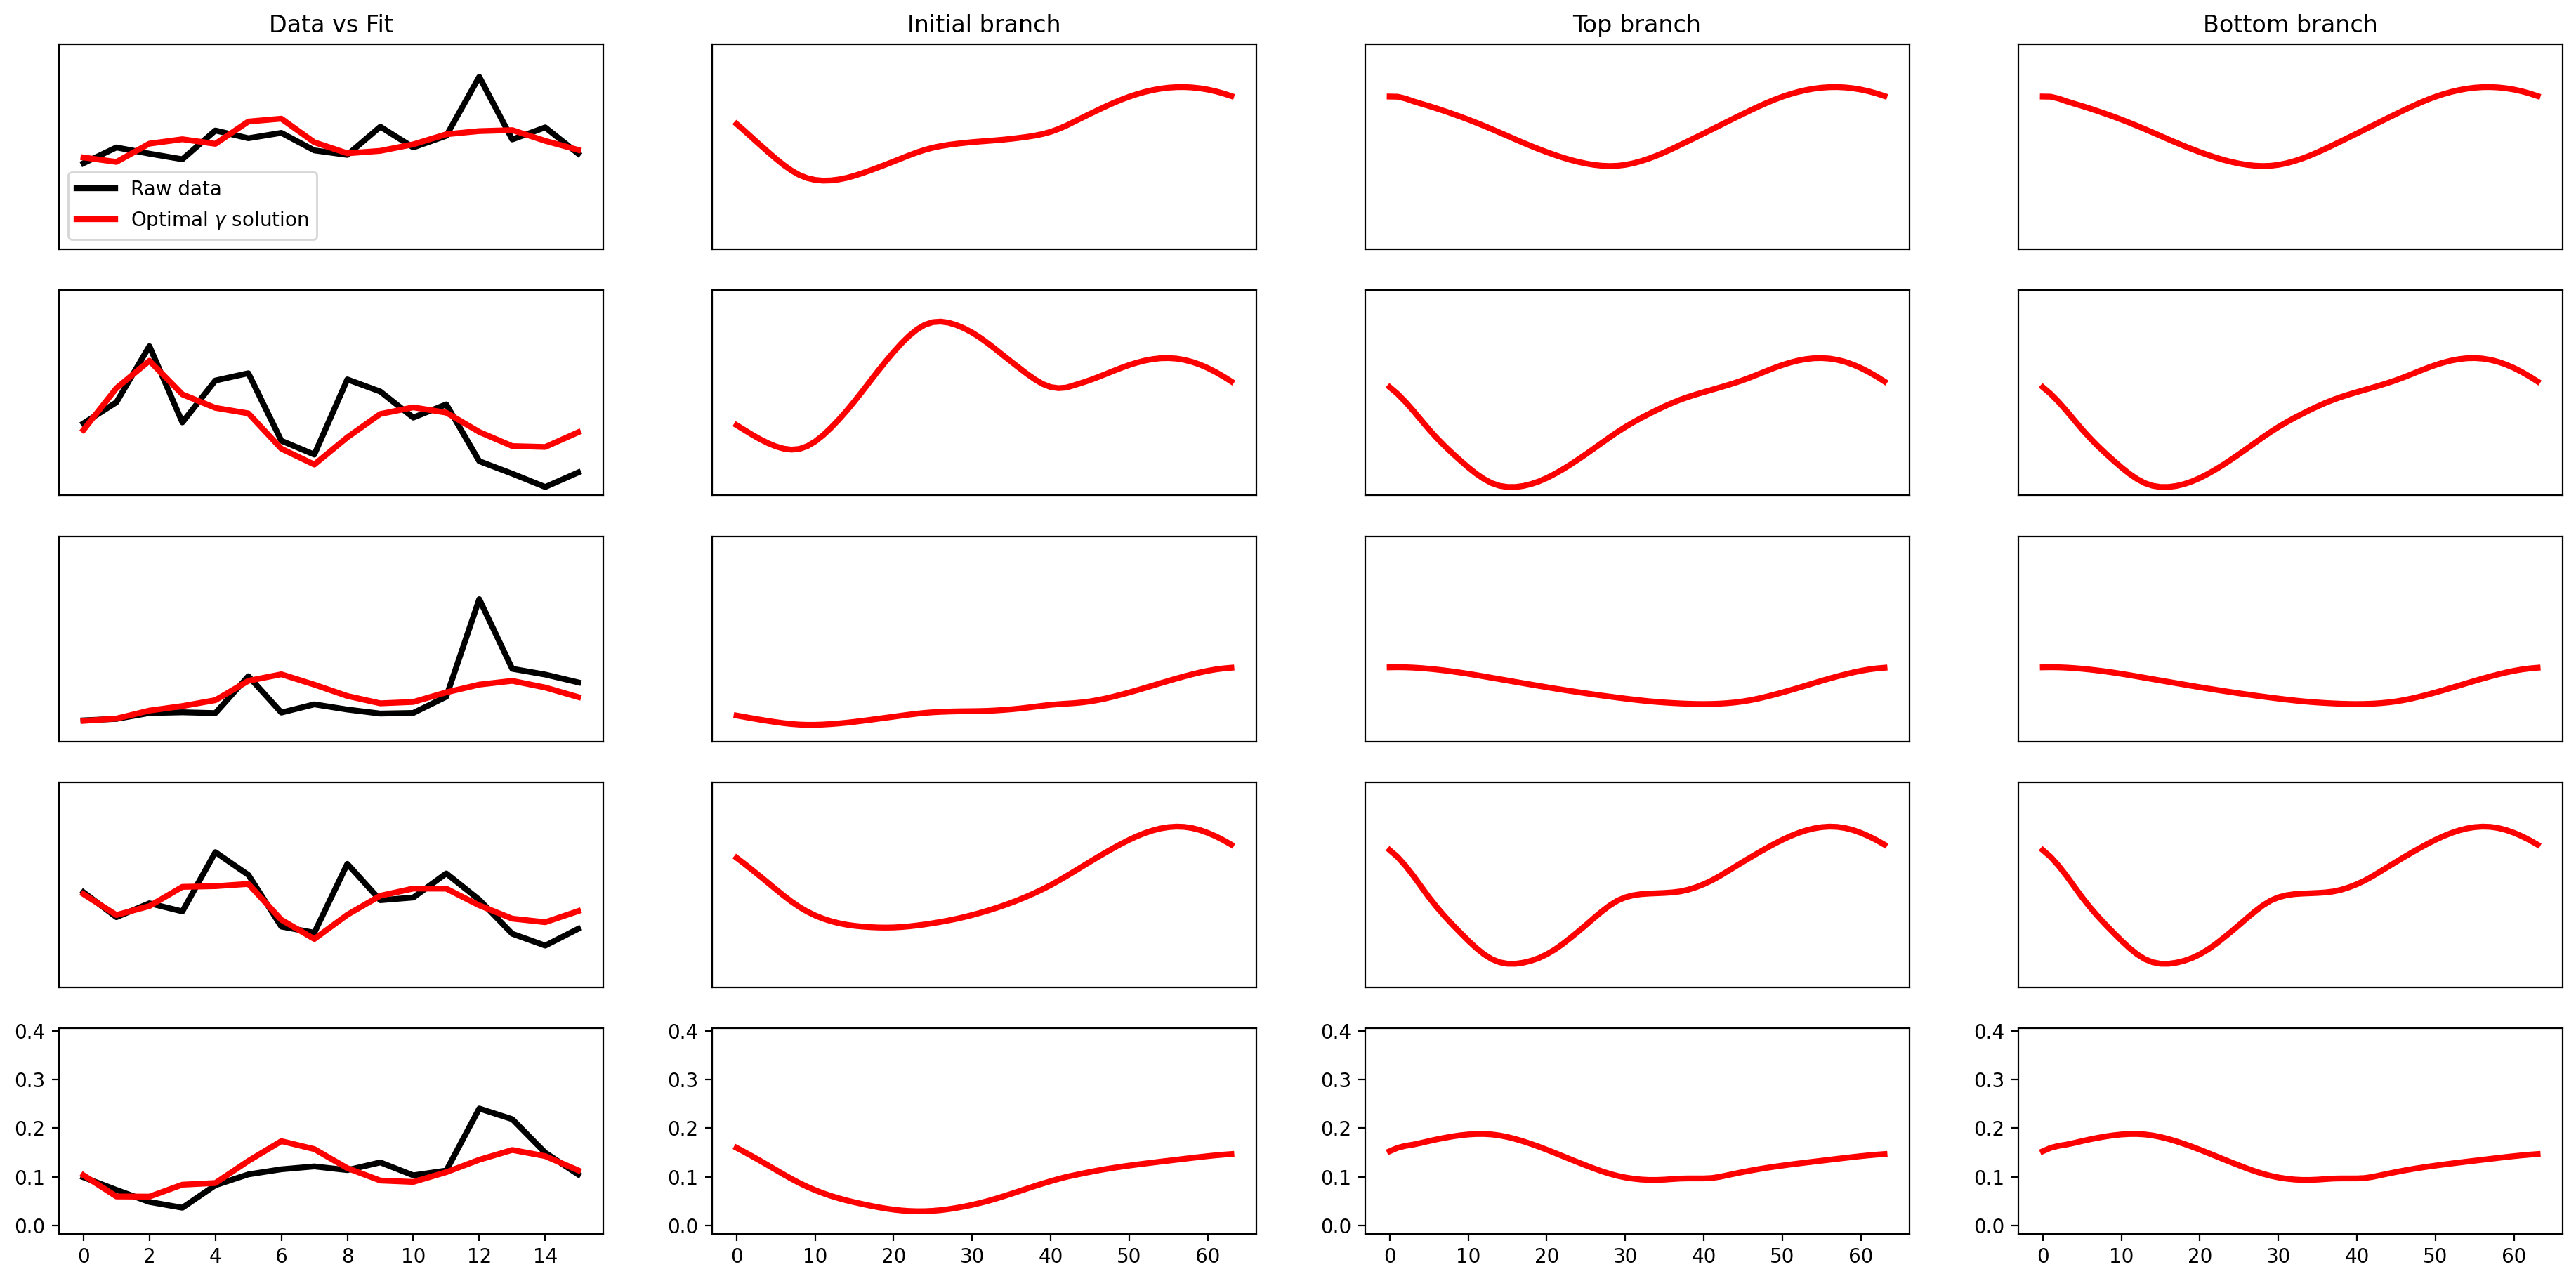

In [369]:
plot_example_fits(chromatin_solver)

In [278]:
from src.chromatin_deconvolution_solver import plot_example_fits
from src.chromatin_deconvolution_solver import plot_branches
from src.chromatin_model import plot_prediction
from src.geneset import get_deconvolved_geneset
from src.sgd import get_orfname

def deconvolve_and_plot(gene_name, output_directory):
    genes = get_deconvolved_geneset()

    orfname = get_orfname(gene_name)

    gene = genes.loc[orfname]
    tss = gene.TSS
    chrom = gene.chr
    mnase_span = tss-1200, tss+1200

    chromatin_model = ChromatinModel(config1)
    chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)

    chromatin_solver = ChromatinDeconvolveSolver(config1, 
        chromatin_model.G, N, b, f_rep, padding_type=padding_type)
    full_deconvolved_F = chromatin_solver.deconvolve_G_iteratively(gamma=2e-4)
    np.save(f"{output_directory}/{gene_name}_F.npy", full_deconvolved_F)

    fig = plot_branches(chromatin_model, full_deconvolved_F)
    plt.savefig(f"{output_directory}/{gene_name}_branches.png")
    plt.close(fig)

    fig = plot_prediction(chromatin_model, N, full_deconvolved_F, f_rep, b)
    plt.savefig(f"{output_directory}/{gene_name}_prediction.png")
    plt.close(fig)

    fig = plot_example_fits(chromatin_solver)
    plt.savefig(f"{output_directory}/{gene_name}_curves.png")
    plt.close(fig)

In [282]:
from src.utils import mkdir_safe

output_directory = 'output/daughter_specific_chromatin_sweep_kappa5e-3'
mkdir_safe(output_directory)


Creating directory: output/daughter_specific_chromatin_sweep_kappa5e-3...Directory exists. Skipping.


In [167]:
from src.sgd import get_orfname
from src.sgd import read_nondubious_genes_dataset

genes = read_nondubious_genes_dataset()
# Let's look at SSK22 and examine whether we can tune the smoothing of the top and bottom 
# branches to an equal level of variability....and understand the reasoning behind
# the differences in variability.

orfname = get_orfname('SSK22')

gene = genes.loc[orfname]
tss = gene.TSS
chrom = gene.chr
mnase_span = tss-200, tss+200

chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)

Loading chromosome reads: 3
Applying a normalization for length distribution


In [168]:
from src.chromatin_gamma_search import ChromatinFindOptimalGamma
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

In [ ]:
from src.chromatin_deconvolution_solver import dummy_N_frep_b

N, f_rep, b = dummy_N_frep_b(config1)

In [ ]:
def subset_select_highest_G_indices(G, num_examples=5):
    G_max_df = pd.DataFrame({'max_value': G.max(axis=0), 
        'index': np.arange(G.shape[1])})
    highest_Gs = G_max_df.sort_values('max_value', 
        ascending=False).head(num_examples)['index'].values
    G_values = G[:, highest_Gs].copy()
    return G_values, highest_Gs

G_values, highest_Gs = subset_select_highest_G_indices(chromatin_model.G)

In [372]:
scale = 1
chromatin_solver = ChromatinDeconvolveSolver(config1, 
    G_values, N, b, f_rep)

0/5 - 00:00:00.362


Completed. - 00:02:14.457


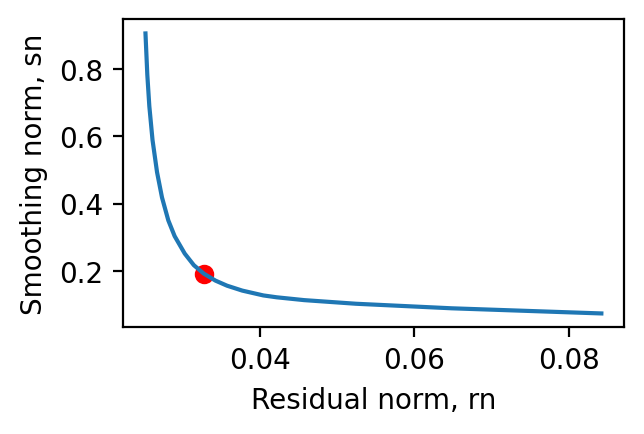

In [394]:
# Simple sanity check, let's lower the gamma and raise kappa
# Idea:
# Less smoothing enforcement, but higher regularization. Will require some tuning
# to find appropriate balance, interested in high signal to noise ratio.
# We can characterize the signal and noise through known genes

chrom_find_gamma = ChromatinFindOptimalGamma(chromatin_solver, gamma_min=0.00001,
                                            gamma_max=0.01, verbose=False,
                                            kappa=0.01)
chrom_find_gamma.find_optimal_gamma()

In [401]:
chrom_find_gamma.gamma_optimizer.optimal_gamma

0.0004056273117911185

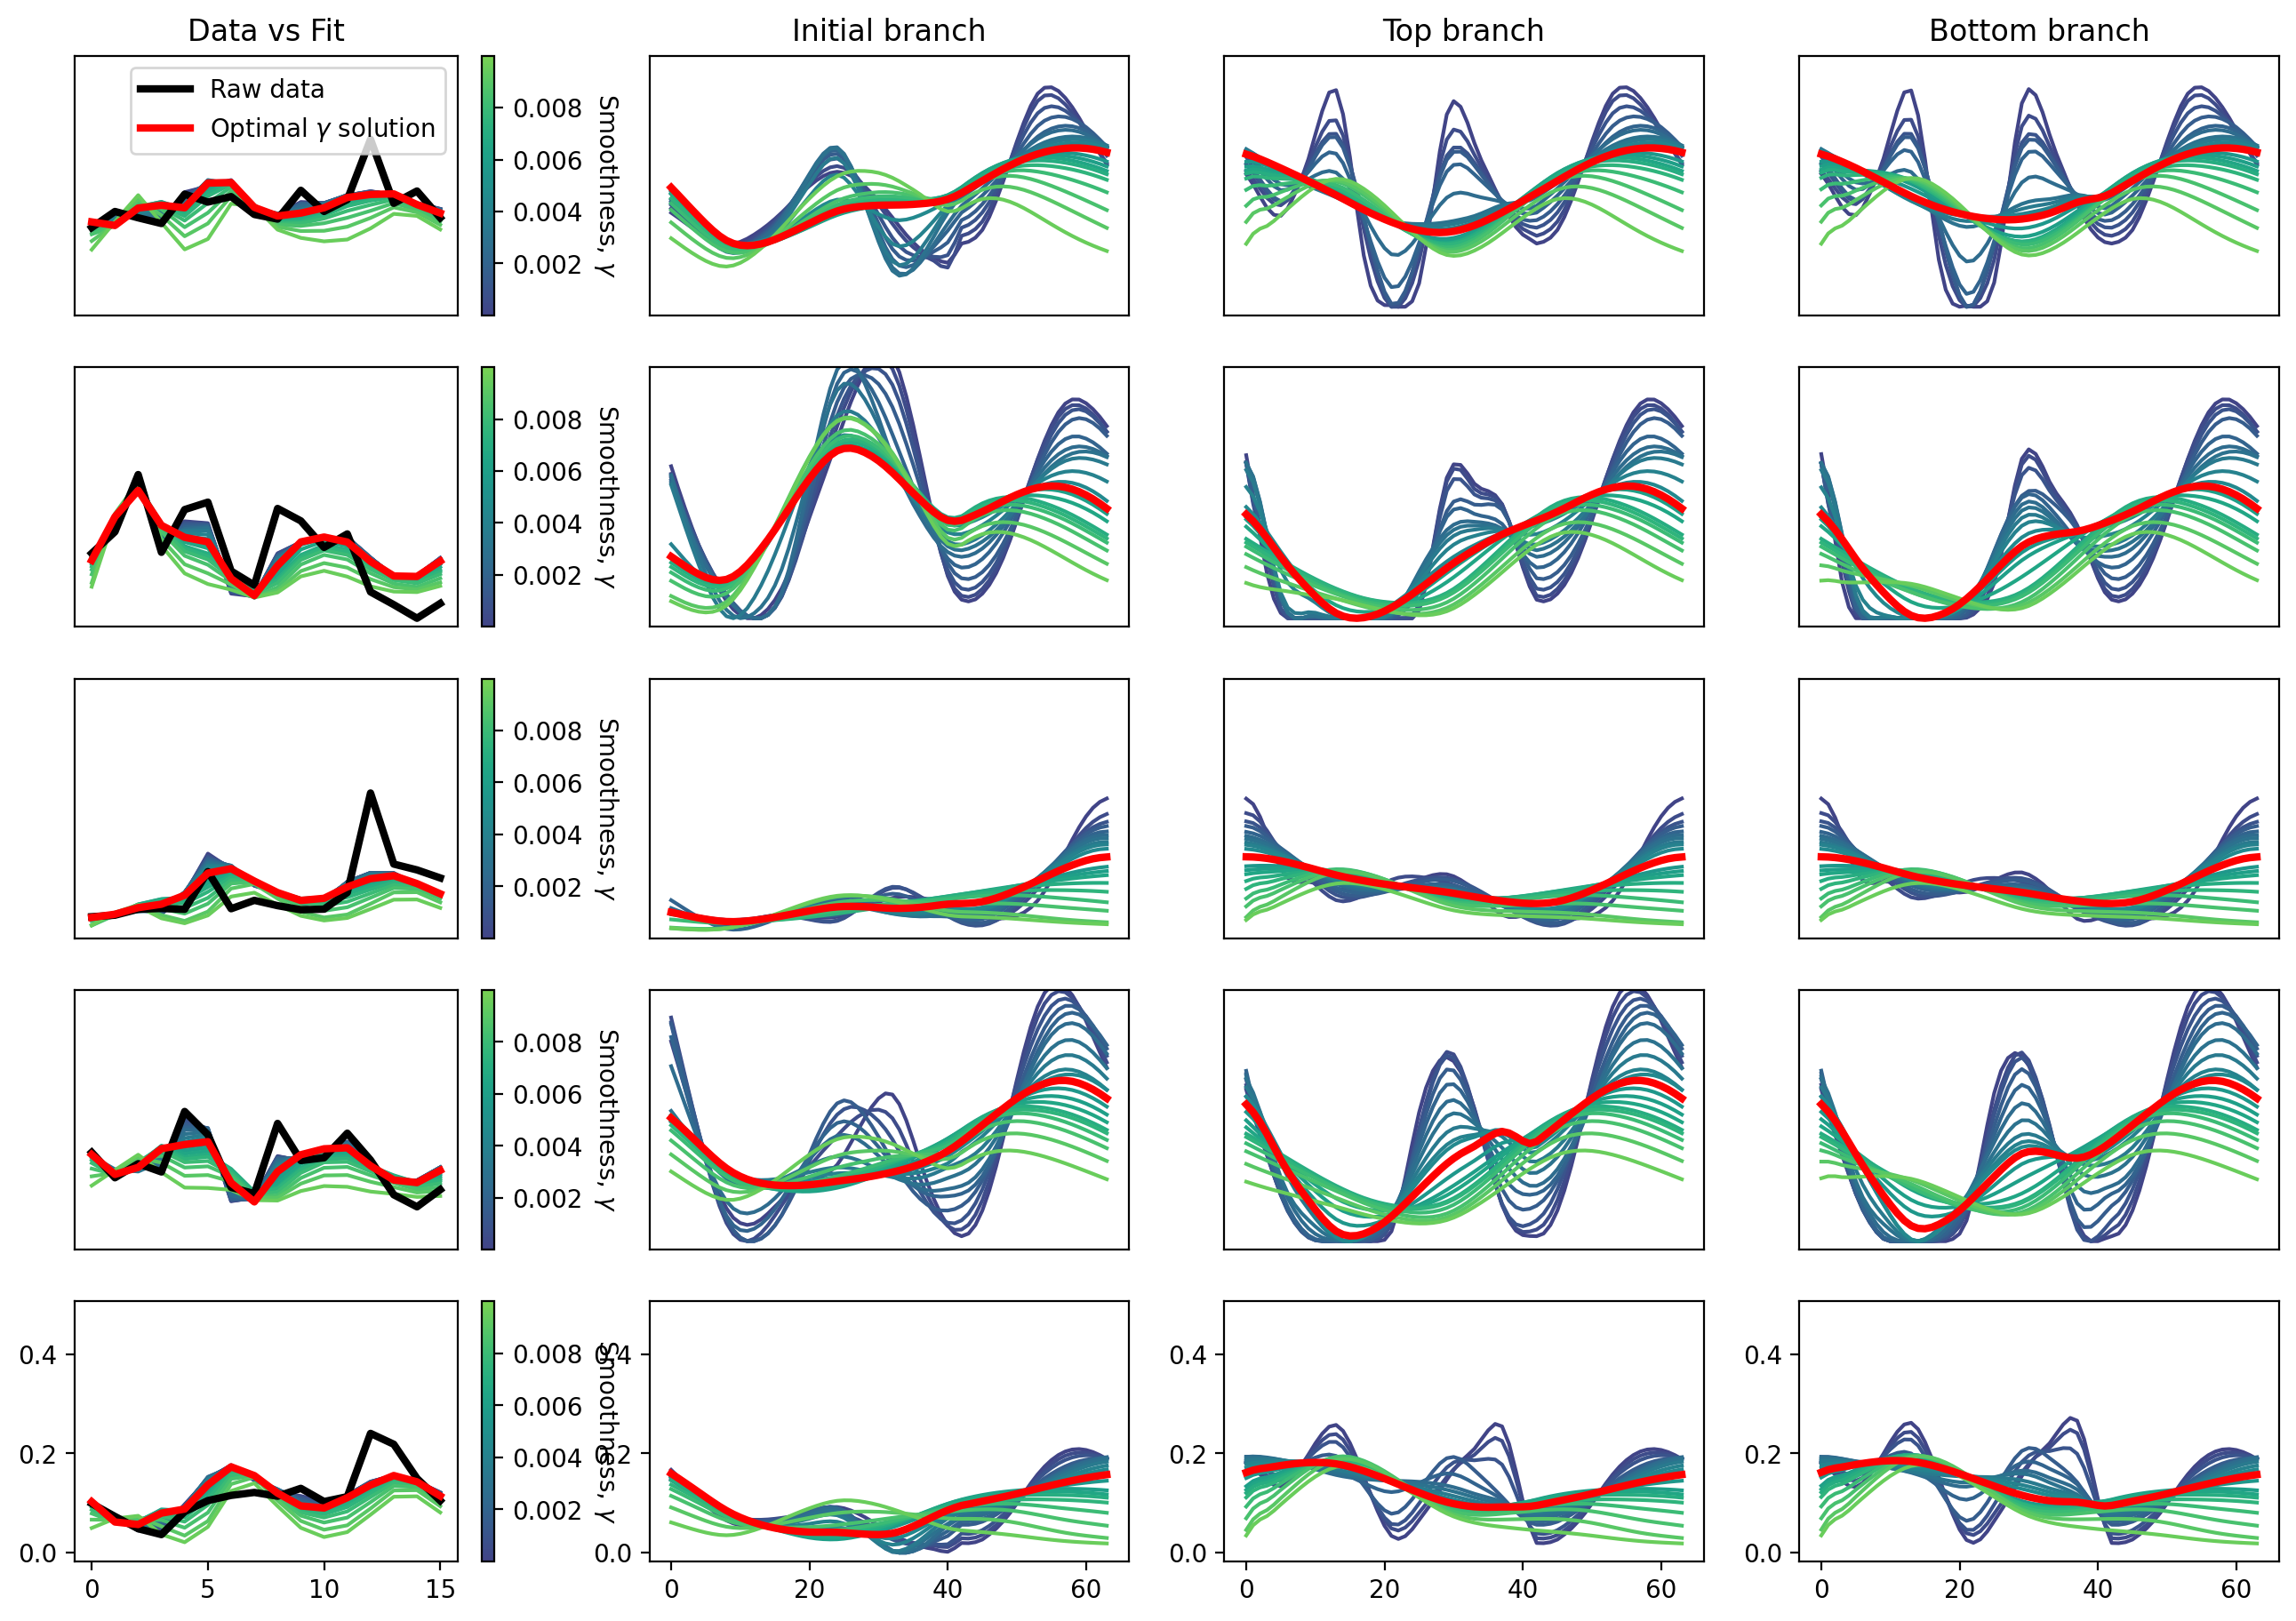

In [395]:
_ = chrom_find_gamma.plot_gamma_sweep()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


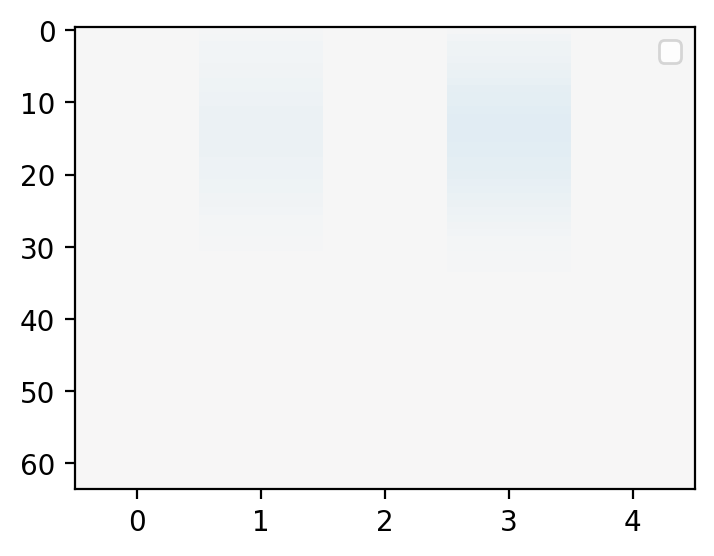

In [399]:
F_t = chrom_find_gamma.chromatin_solver.F[t_indices]
F_b = chrom_find_gamma.chromatin_solver.F[b_indices]

plt.figure(figsize=(4, 3))
plt.imshow(F_t - F_b, vmin=-0.5, vmax=0.5, cmap='RdBu_r', aspect='auto')
plt.legend()

